
# 📌 1. INSTALL & IMPORT DEPENDENCIES

In [1]:
!pip install gdown scikit-image ipywidgets --quiet

import gdown
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
from skimage import io, color
from skimage.color import deltaE_cie76
import ipywidgets as widgets
from ipywidgets import interact
from IPython.display import display, Markdown

# Enable interactive widgets in Colab
from google.colab import output
output.enable_custom_widget_manager()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 14.8 MB/s eta 0:00:00


# 📌 2. DOWNLOAD IMAGE FROM GOOGLE DRIVE

## Step 1: Download and Load Image
We will use an image from Google Drive for color space conversions.

Downloading...
From: https://drive.google.com/uc?id=1CPXI4SQSRRlq5HKJkW6_D5ezpxuN7B3R
To: /content/image.jpg
100%|██████████| 92.6k/92.6k [00:00<00:00, 30.2MB/s]


Original image shape: (408, 612, 3)


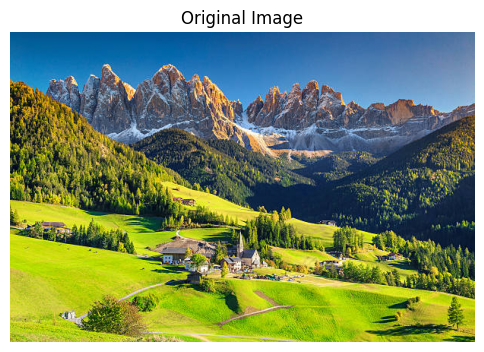

In [2]:
display(Markdown("## Step 1: Download and Load Image\n"
                 "We will use an image from Google Drive for color space conversions."))

# Google Drive image link
url = "https://drive.google.com/uc?id=1CPXI4SQSRRlq5HKJkW6_D5ezpxuN7B3R"  # extracted file ID
output_path = "image.jpg"
gdown.download(url, output_path, quiet=False)

# Load image
image = io.imread(output_path)
image_f = image / 255.0  # Normalize for calculations
h, w, _ = image.shape

print(f"Original image shape: {image.shape}")
plt.figure(figsize=(6,6))
plt.imshow(image_f)
plt.title("Original Image")
plt.axis('off')
plt.show()

# 📌 3. RGB and CMY Color Models


## RGB and CMY Color Spaces
- **RGB (Red, Green, Blue):** Additive color model, combines light.
- **CMY (Cyan, Magenta, Yellow):** Subtractive model, used in printing.
- **CMY = 1 - RGB**


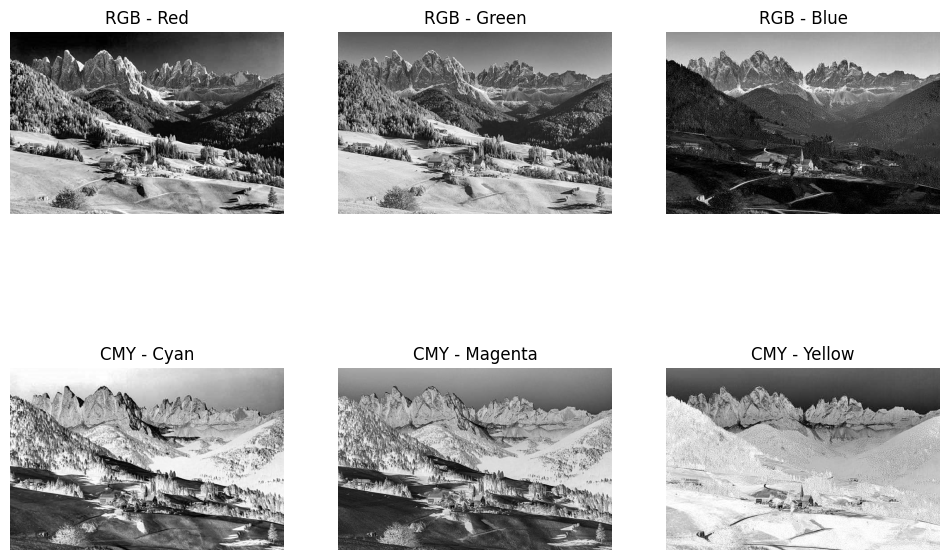

In [3]:
display(Markdown("""
## RGB and CMY Color Spaces
- **RGB (Red, Green, Blue):** Additive color model, combines light.
- **CMY (Cyan, Magenta, Yellow):** Subtractive model, used in printing.
- **CMY = 1 - RGB**
"""))

# Compute CMY
cmy = 1.0 - image_f

# Visualize RGB and CMY channels
fig, axes = plt.subplots(2, 3, figsize=(12,8))
for i, (ch, name) in enumerate(zip(np.moveaxis(image_f, -1, 0), ['Red','Green','Blue'])):
    axes[0,i].imshow(ch, cmap='gray')
    axes[0,i].set_title(f"RGB - {name}")
    axes[0,i].axis('off')

for i, (ch, name) in enumerate(zip(np.moveaxis(cmy, -1, 0), ['Cyan','Magenta','Yellow'])):
    axes[1,i].imshow(ch, cmap='gray')
    axes[1,i].set_title(f"CMY - {name}")
    axes[1,i].axis('off')

plt.show()

# 📌 4. CIE XYZ and Chromaticity



## CIE XYZ Color Space
- **Linear model** representing human vision sensitivity.
- Conversion formula based on RGB to XYZ matrix.
- Chromaticity coordinates:  
  \( x = \frac{X}{X+Y+Z}, y = \frac{Y}{X+Y+Z} \)


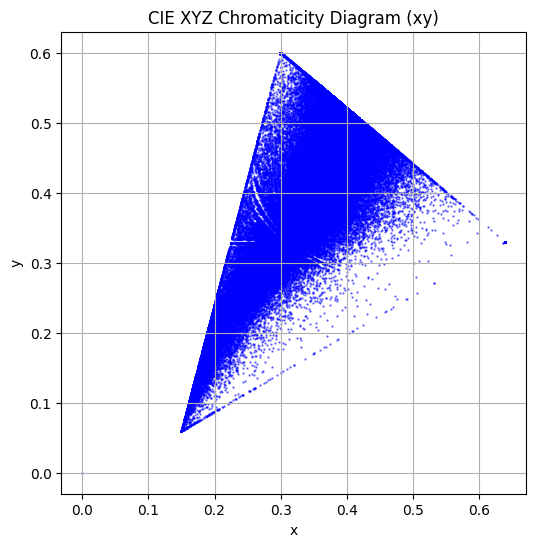

In [4]:
display(Markdown("""
## CIE XYZ Color Space
- **Linear model** representing human vision sensitivity.
- Conversion formula based on RGB to XYZ matrix.
- Chromaticity coordinates:
  \\( x = \\frac{X}{X+Y+Z}, y = \\frac{Y}{X+Y+Z} \\)
"""))

xyz = color.rgb2xyz(image_f)

# Compute chromaticity
X, Y, Z = xyz[:,:,0], xyz[:,:,1], xyz[:,:,2]
x_chroma = X / (X + Y + Z + 1e-6)
y_chroma = Y / (X + Y + Z + 1e-6)

plt.figure(figsize=(6,6))
plt.scatter(x_chroma.flatten(), y_chroma.flatten(), s=0.5, color='blue', alpha=0.5)
plt.title("CIE XYZ Chromaticity Diagram (xy)")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()

# 📌 5. CIELAB Color Space

<>:3: SyntaxWarning: invalid escape sequence '\*'
<>:3: SyntaxWarning: invalid escape sequence '\*'
/tmp/ipython-input-3108129172.py:3: SyntaxWarning: invalid escape sequence '\*'
  - **L\***: Lightness (0=black, 100=white)



## CIELAB Color Space
- **L\***: Lightness (0=black, 100=white)  
- **a\***: Green (-) to Red (+)  
- **b\***: Blue (-) to Yellow (+)  
- Designed for perceptual uniformity.


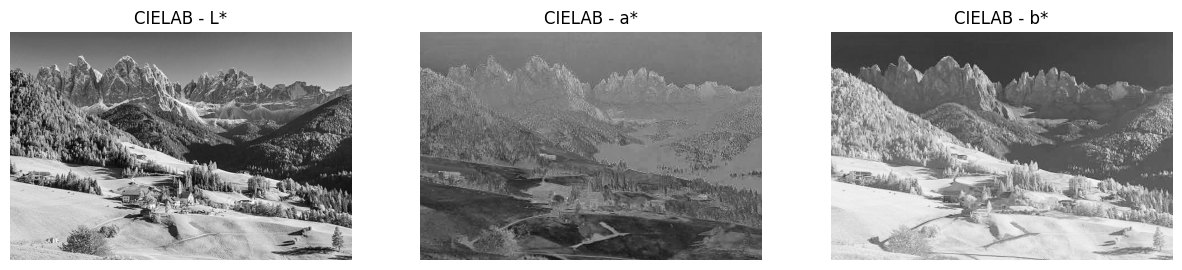

In [5]:
display(Markdown("""
## CIELAB Color Space
- **L\***: Lightness (0=black, 100=white)
- **a\***: Green (-) to Red (+)
- **b\***: Blue (-) to Yellow (+)
- Designed for perceptual uniformity.
"""))

lab = color.rgb2lab(image_f)

fig, axes = plt.subplots(1, 3, figsize=(15,5))
for ax, ch, name in zip(axes, np.moveaxis(lab, -1, 0), ['L*','a*','b*']):
    ax.imshow(ch, cmap='gray')
    ax.set_title(f"CIELAB - {name}")
    ax.axis('off')

plt.show()

# 📌 6. YIQ, YCbCr, HSV Models


## YIQ, YCbCr, and HSV Models
- **YIQ:** Luminance + two chrominance channels (used in NTSC TV)
- **YCbCr:** Digital video standard (luma + color difference)
- **HSV:** Hue, Saturation, Value – user-friendly color model.


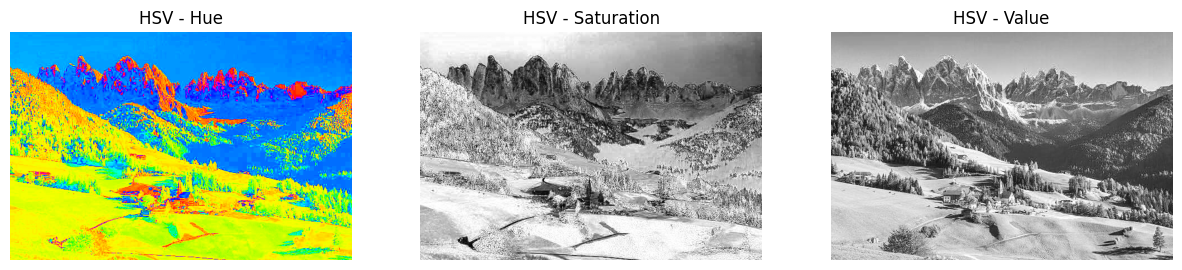

In [6]:
display(Markdown("""
## YIQ, YCbCr, and HSV Models
- **YIQ:** Luminance + two chrominance channels (used in NTSC TV)
- **YCbCr:** Digital video standard (luma + color difference)
- **HSV:** Hue, Saturation, Value – user-friendly color model.
"""))

# HSV
hsv = mcolors.rgb_to_hsv(image_f)

# Visualize HSV
fig, axes = plt.subplots(1, 3, figsize=(15,5))
for ax, ch, name in zip(axes, np.moveaxis(hsv, -1, 0), ['Hue','Saturation','Value']):
    ax.imshow(ch, cmap='hsv' if name=='Hue' else 'gray')
    ax.set_title(f"HSV - {name}")
    ax.axis('off')

plt.show()

In [7]:
display(Markdown("""
## **NOTE for Students**
As you can see, each color space serves a different purpose:
- **RGB/CMY**: Device-dependent, good for display or printing.
- **XYZ/Chromaticity**: Foundation for all standardized color spaces.
- **CIELAB**: Perceptual uniformity, useful for color difference (ΔE).
- **YIQ/YCbCr**: Video and broadcasting standards.
- **HSV**: Intuitive for color selection (used in design tools).
"""))


## **NOTE for Students**
As you can see, each color space serves a different purpose:
- **RGB/CMY**: Device-dependent, good for display or printing.
- **XYZ/Chromaticity**: Foundation for all standardized color spaces.
- **CIELAB**: Perceptual uniformity, useful for color difference (ΔE).
- **YIQ/YCbCr**: Video and broadcasting standards.
- **HSV**: Intuitive for color selection (used in design tools).


#📌 7. Compute ΔE between two patches

<>:4: SyntaxWarning: invalid escape sequence '\D'
<>:4: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipython-input-4186369482.py:4: SyntaxWarning: invalid escape sequence '\D'
  \\( \Delta E = \sqrt{(L_1 - L_2)^2 + (a_1 - a_2)^2 + (b_1 - b_2)^2} \\)



## ΔE (CIE76) Color Difference
Formula:  
\( \Delta E = \sqrt{(L_1 - L_2)^2 + (a_1 - a_2)^2 + (b_1 - b_2)^2} \)



**Patch 1 (L*a*b*):** [ 52.22605426  -2.72796166 -30.19755484]  
**Patch 2 (L*a*b*):** [42.14342399 -5.05898251 28.68931469]  
### ΔE (CIE76) = **59.79**
Interpretation:
- ΔE < 1: Not perceptible
- 1–2: Perceptible through close observation
- 2–10: Noticeable
- >10: Very different


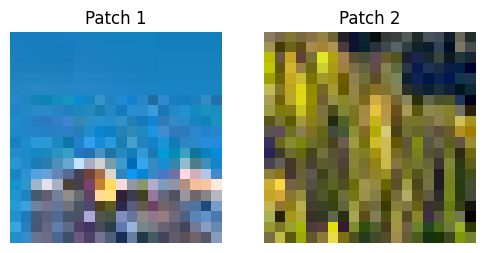

In [8]:
display(Markdown("""
## ΔE (CIE76) Color Difference
Formula:
\\( \Delta E = \sqrt{(L_1 - L_2)^2 + (a_1 - a_2)^2 + (b_1 - b_2)^2} \\)
"""))

# Patch coordinates (students can change these)
patch1_top, patch1_left = 50, 50
patch2_top, patch2_left = 150, 150
patch_size = 20

patch1 = lab[patch1_top:patch1_top+patch_size, patch1_left:patch1_left+patch_size]
patch2 = lab[patch2_top:patch2_top+patch_size, patch2_left:patch2_left+patch_size]

mean1 = np.mean(patch1.reshape(-1,3), axis=0)
mean2 = np.mean(patch2.reshape(-1,3), axis=0)

deltaE = deltaE_cie76(mean1[np.newaxis,:], mean2[np.newaxis,:])[0]

display(Markdown(f"""
**Patch 1 (L*a*b*):** {mean1}
**Patch 2 (L*a*b*):** {mean2}
### ΔE (CIE76) = **{deltaE:.2f}**
Interpretation:
- ΔE < 1: Not perceptible
- 1–2: Perceptible through close observation
- 2–10: Noticeable
- >10: Very different
"""))

plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plt.imshow(image_f[patch1_top:patch1_top+patch_size, patch1_left:patch1_left+patch_size])
plt.title("Patch 1"); plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(image_f[patch2_top:patch2_top+patch_size, patch2_left:patch2_left+patch_size])
plt.title("Patch 2"); plt.axis('off')
plt.show()

# 📌 8. Interactive Pixel Inspector

In [9]:
display(Markdown("""
## Interactive Pixel Inspector
Pick a pixel (row, col) and view its values in different color spaces.
"""))

def inspect_pixel(row=100, col=100):
    row = np.clip(row, 0, h-1)
    col = np.clip(col, 0, w-1)

    rgb = image_f[row, col]
    cmy = 1.0 - rgb
    hsv_val = mcolors.rgb_to_hsv(rgb[np.newaxis,:])[0]
    yiq_val = np.array([0.299*rgb[0]+0.587*rgb[1]+0.114*rgb[2],
                        0.596*rgb[0]-0.274*rgb[1]-0.322*rgb[2],
                        0.211*rgb[0]-0.523*rgb[1]+0.312*rgb[2]])
    ycbcr_val = np.array([
        0.299*rgb[0]*255+0.587*rgb[1]*255+0.114*rgb[2]*255,
        (-0.168736*rgb[0]*255-0.331264*rgb[1]*255+0.5*rgb[2]*255)+128,
        (0.5*rgb[0]*255-0.418688*rgb[1]*255-0.081312*rgb[2]*255)+128
    ])
    lab_val = lab[row, col]
    xyz_val = xyz[row, col]

    display(Markdown(f"""
    ### Pixel ({row},{col}) Values:
    - **RGB:** {rgb}
    - **CMY:** {cmy}
    - **HSV:** {hsv_val}
    - **YIQ:** {yiq_val}
    - **YCbCr:** {ycbcr_val}
    - **CIE XYZ:** {xyz_val}
    - **CIELAB:** {lab_val}
    """))

    plt.figure(figsize=(2,2))
    plt.imshow(np.ones((50,50,3))*rgb)
    plt.title("Selected Pixel Color")
    plt.axis('off')
    plt.show()

interact(inspect_pixel, row=widgets.IntSlider(min=0, max=h-1, step=1, value=h//2),
         col=widgets.IntSlider(min=0, max=w-1, step=1, value=w//2))


## Interactive Pixel Inspector
Pick a pixel (row, col) and view its values in different color spaces.


interactive(children=(IntSlider(value=204, description='row', max=407), IntSlider(value=306, description='col'…

<function __main__.inspect_pixel(row=100, col=100)>

Features of this Notebook:

    ✔ Full definitions and formulas for each color space
    ✔ Visualizations (channels, chromaticity diagram)
    ✔ ΔE computation between two patches
    ✔ Interactive pixel inspector with ipywidgets